In [99]:
# start by importing the necessary packages
import cv2
import os
import matplotlib.pyplot as plt
import json
import threading
import numpy as np
import matplotlib.cm as cm
from scipy.interpolate import interp1d
from skimage import color, segmentation, measure, morphology, filters
from sklearn.cluster import KMeans
import pandas as pd
import os

# import the detector
from GMMDetector import MaterialDetector
import sys
sys.path.append("../../../src")
from image_container import Image_Container

os.environ["OMERO_HOST"] = "100.125.247.59"
os.environ["OMERO_PORT"] = "4064"
os.environ["OMERO_USERNAME"] = "root"
os.environ["OMERO_PASSWORD"] = "omero"


def showImage(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.imshow(img)

image_container = Image_Container()

In [100]:
def whitebalance(image):
    # return image
    result = image.astype(np.float32)
    quantized = (image // 8) * 8
    brightness = quantized.sum(axis=2)
    mask = brightness > 30
    filtered = quantized[mask]
    
    colors_as_int = (filtered[:, 0].astype(np.int32) << 16) | (filtered[:, 1].astype(np.int32) << 8) | filtered[:, 2].astype(np.int32)
    
    counts = np.bincount(colors_as_int)
    most_common_int = np.argmax(counts)
    
    color = np.array([
        (most_common_int >> 16) & 0xFF,
        (most_common_int >> 8) & 0xFF,
        most_common_int & 0xFF
    ], dtype=np.float32)
    
    avg_gray = (color[0] + color[1] + color[2]) / 3.0
    scale_r = avg_gray / color[0] if color[0] > 0 else 1.0
    scale_g = avg_gray / color[1] if color[1] > 0 else 1.0
    scale_b = avg_gray / color[2] if color[2] > 0 else 1.0
    # print(f"Most common color: RGB({color[0]}, {color[1]}, {color[2]})")
    # print(f"Scale factors: R={scale_r:.3f}, G={scale_g:.3f}, B={scale_b:.3f}")
    result[:, :, 0] *= scale_r
    result[:, :, 1] *= scale_g
    result[:, :, 2] *= scale_b

    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

def greyscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [101]:
# class FlinderDetector:
#     """
#     Simplified Flinder flake detection algorithm.
#     Uses color-based segmentation with KBGR channels and calibration data.
#     """
    
#     def __init__(self, config, debug=False):
#         """
#         Args:
#             config: dict with detection parameters:
#                 'use_channels': {'k': bool, 'b': bool, 'g': bool, 'r': bool}
#                 'blur_size': int, local averaging kernel size (default 5)
#                 'median_blur_size': int, preprocessing median blur (default 7)
#                 'mask_median_blur_size': int, post-combination median blur (default 5)
#                 'min_area': float, minimum contour area in pixels (default 100)
#                 'criteria': dict with filtering thresholds:
#                     'k_std': {'max': float}, 'b_std': {'max': float},
#                     'g_std': {'max': float}, 'r_std': {'max': float},
#                     'area_perimeter_ratio': {'min': float, 'max': float},
#                     'aspect_ratio': {'min': float, 'max': float}
#             debug: bool, if True show intermediate images
#         """
#         self.debug = debug

#         # Build config with defaults, then overlay user overrides
#         self.config = config
        
#     def extract_kbgr(self, image):
#         """Extract K (gray), B (blue), G (green), R (red) channels."""
#         b, g, r = cv2.split(image)
#         k = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#         return k.astype("uint8"), b.astype("uint8"), g.astype("uint8"), r.astype("uint8")

#     @staticmethod
#     def compute_mask_values(calibration):
#         """Compute per-interval mask value dicts from calibration data.
        
#         Replicates Flinder's get_mask_values() pipeline:
#         - Divides the thickness range into N intervals
#         - For each interval, interpolates each channel's calibration curve
#         - Computes [min - error, max + error] for each channel
        
#         Args:
#             calibration: dict with keys:
#                 'thickness': list/array of thickness (or layer) values, e.g. [1, 2, 3, 4]
#                 'k', 'b', 'g', 'r': list/array of mean channel values at each thickness
#                 'k_error', 'b_error', 'g_error', 'r_error': error bars at each thickness
#                 'number_of_intervals': int, how many segments to divide the range into
        
#         Returns:
#             List of dicts, one per interval:
#                 [{'k': {'min': int, 'max': int}, 'b': {...}, 'g': {...}, 'r': {...}}, ...]
#         """
#         thickness = np.array(calibration['thickness'], dtype=float)
#         n_intervals = int(calibration.get('number_of_intervals', 1))
        
#         segments = np.linspace(thickness.min(), thickness.max(), n_intervals + 1)
        
#         mask_values_list = []
#         for i in range(n_intervals):
#             tmin, tmax = segments[i], segments[i + 1]
#             interval = {}
#             for ch in ['k', 'b', 'g', 'r']:
#                 ch_min, ch_max = FlinderDetector._find_minmax_segment(
#                     thickness,
#                     calibration[ch],
#                     tmin, tmax,
#                     calibration[f'{ch}_error'],
#                 )
#                 interval[ch] = {'min': ch_min, 'max': ch_max}
#             mask_values_list.append(interval)
        
#         return mask_values_list
    
#     def create_mask(self, channel, lmin, lmax):
#         square = self.config.get('blur_size', 5)
#         blurred = cv2.blur(channel, (square, square)).astype("uint8")
#         _, binary = cv2.threshold(blurred, lmin, 255, cv2.THRESH_BINARY_INV)
#         _, binary2 = cv2.threshold(blurred, lmax, 255, cv2.THRESH_BINARY_INV)
#         return binary - binary2

#     def make_selection(self, k, b, g, r, mask_values):
#         use = self.config['use_channels']
        
#         if use.get('k', False):
#             gray_mask = self.create_mask(k, mask_values['k']['min'], mask_values['k']['max'])
#         else:
#             gray_mask = self.create_mask(k, 0, 255)
#         self._debug_image(gray_mask, "K channel mask")
        
#         if use.get('b', False):
#             blue_mask = self.create_mask(b, mask_values['b']['min'], mask_values['b']['max'])
#             gray_mask[blue_mask < 0.5] = 0
#         self._debug_image(gray_mask, "After B channel AND")
        
#         if use.get('g', False):
#             green_mask = self.create_mask(g, mask_values['g']['min'], mask_values['g']['max'])
#             gray_mask[green_mask < 0.5] = 0
#         self._debug_image(gray_mask, "After G channel AND")
        
#         if use.get('r', False):
#             red_mask = self.create_mask(r, mask_values['r']['min'], mask_values['r']['max'])
#             gray_mask[red_mask < 0.5] = 0
#         self._debug_image(gray_mask, "After R channel AND")
        
#         gray_mask = cv2.medianBlur(gray_mask, self.config.get('mask_median_blur_size', 5))
#         return gray_mask
    

class FlinderDetector:
    """Flinder-style flake detection with KBGR channel masking."""

    def __init__(self, config=None, debug=False):

        self.debug = debug

        self.config = {
            "use_channels": {"k": True, "b": True, "g": True, "r": True},
            "blur_size": 5,
            "median_blur_size": 7,
            "mask_median_blur_size": 5,
            "min_area": 100,
            "criteria": {
                "k_std": {"max": 15},
                "b_std": {"max": 15},
                "g_std": {"max": 15},
                "r_std": {"max": 15},
                "area_perimeter_ratio": {"min": 0.05, "max": 100000},
                "aspect_ratio": {"min": 1, "max": 6},
            },
        }
        if config is not None:
            for key, value in config.items():
                if (
                    isinstance(value, dict)
                    and key in self.config
                    and isinstance(self.config[key], dict)
                ):
                    self.config[key].update(value)
                else:
                    self.config[key] = value

    @staticmethod
    def extract_kbgr(image):
        b, g, r = cv2.split(image)
        k = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        return (
            k.astype("uint8"),
            b.astype("uint8"),
            g.astype("uint8"),
            r.astype("uint8"),
        )

    def create_mask(self, channel, lmin, lmax):
        square = self.config.get("blur_size", 5)
        blurred = cv2.blur(channel, (square, square)).astype("uint8")
        _, binary = cv2.threshold(blurred, lmin, 255, cv2.THRESH_BINARY_INV)
        _, binary2 = cv2.threshold(blurred, lmax, 255, cv2.THRESH_BINARY_INV)
        return binary - binary2

    def make_selection(self, k, b, g, r, mask_values):
        use = self.config["use_channels"]

        if use.get("k", False):
            gray_mask = self.create_mask(
                k, mask_values["k"]["min"], mask_values["k"]["max"]
            )
        else:
            gray_mask = self.create_mask(k, 0, 255)

        if use.get("b", False):
            blue_mask = self.create_mask(
                b, mask_values["b"]["min"], mask_values["b"]["max"]
            )
            gray_mask[blue_mask < 0.5] = 0

        if use.get("g", False):
            green_mask = self.create_mask(
                g, mask_values["g"]["min"], mask_values["g"]["max"]
            )
            gray_mask[green_mask < 0.5] = 0

        if use.get("r", False):
            red_mask = self.create_mask(
                r, mask_values["r"]["min"], mask_values["r"]["max"]
            )
            gray_mask[red_mask < 0.5] = 0

        ms = self.config.get("mask_median_blur_size", 5)
        gray_mask = cv2.medianBlur(gray_mask, ms)
        return gray_mask

    def make_channel_masks(self, k, b, g, r, mask_values):
        """Return individual channel masks for visualization."""
        use = self.config["use_channels"]
        masks = {}
        if use.get("k", False):
            masks["k"] = self.create_mask(
                k, mask_values["k"]["min"], mask_values["k"]["max"]
            )
        if use.get("b", False):
            masks["b"] = self.create_mask(
                b, mask_values["b"]["min"], mask_values["b"]["max"]
            )
        if use.get("g", False):
            masks["g"] = self.create_mask(
                g, mask_values["g"]["min"], mask_values["g"]["max"]
            )
        if use.get("r", False):
            masks["r"] = self.create_mask(
                r, mask_values["r"]["min"], mask_values["r"]["max"]
            )
        return masks

    def find_contours_in_mask(self, mask, min_area=100):
        contours, _ = cv2.findContours(
            mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
        )
        return [c for c in contours if cv2.contourArea(c) > min_area]

    @staticmethod
    def compute_mask_values(calibration):
        """Compute per-interval mask value dicts from calibration data.
        
        Replicates Flinder's get_mask_values() pipeline:
        - Divides the thickness range into N intervals
        - For each interval, interpolates each channel's calibration curve
        - Computes [min - error, max + error] for each channel
        
        Args:
            calibration: dict with keys:
                'thickness': list/array of thickness (or layer) values, e.g. [1, 2, 3, 4]
                'k', 'b', 'g', 'r': list/array of mean channel values at each thickness
                'k_error', 'b_error', 'g_error', 'r_error': error bars at each thickness
                'number_of_intervals': int, how many segments to divide the range into
        
        Returns:
            List of dicts, one per interval:
                [{'k': {'min': int, 'max': int}, 'b': {...}, 'g': {...}, 'r': {...}}, ...]
        """
        thickness = np.array(calibration['thickness'], dtype=float)
        n_intervals = int(calibration.get('number_of_intervals', 1))
        
        segments = np.linspace(thickness.min(), thickness.max(), n_intervals + 1)
        
        mask_values_list = []
        for i in range(n_intervals):
            tmin, tmax = segments[i], segments[i + 1]
            interval = {}
            for ch in ['k', 'b', 'g', 'r']:
                ch_min, ch_max = FlinderDetector._find_minmax_segment(
                    thickness,
                    calibration[ch],
                    tmin, tmax,
                    calibration[f'{ch}_error'],
                )
                interval[ch] = {'min': ch_min, 'max': ch_max}
            mask_values_list.append(interval)
        
        return mask_values_list
    
    def calculate_contour_statistics(self, contour, k, b, g, r):
        mask = np.zeros(k.shape, np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

        k_v = k[mask > 0.5]
        b_v = b[mask > 0.5]
        g_v = g[mask > 0.5]
        r_v = r[mask > 0.5]

        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        if area == 0:
            area = 1
        if perimeter == 0:
            perimeter = 1
        apr = 16 * area / (perimeter**2)

        rect = cv2.minAreaRect(contour)
        box = cv2.boxPoints(rect)
        d1 = np.linalg.norm(box[0] - box[1])
        d2 = np.linalg.norm(box[1] - box[2])
        if d1 == 0:
            d1 = 1
        if d2 == 0:
            d2 = 1
        ar = max(d1, d2) / min(d1, d2)

        return {
            "k_median": float(np.median(k_v)),
            "k_std": float(np.std(k_v)),
            "b_median": float(np.median(b_v)),
            "b_std": float(np.std(b_v)),
            "g_median": float(np.median(g_v)),
            "g_std": float(np.std(g_v)),
            "r_median": float(np.median(r_v)),
            "r_std": float(np.std(r_v)),
            "area": float(area),
            "perimeter": float(perimeter),
            "area_perimeter_ratio": float(apr),
            "aspect_ratio": float(ar),
        }

    def check_criteria(self, stats):
        crit = self.config["criteria"]
        checks = [
            stats["k_std"] < crit["k_std"]["max"],
            stats["b_std"] < crit["b_std"]["max"],
            stats["g_std"] < crit["g_std"]["max"],
            stats["r_std"] < crit["r_std"]["max"],
            crit["area_perimeter_ratio"]["min"]
            < stats["area_perimeter_ratio"]
            < crit["area_perimeter_ratio"]["max"],
            crit["aspect_ratio"]["min"]
            < stats["aspect_ratio"]
            < crit["aspect_ratio"]["max"],
        ]
        return all(checks)

    def check_color_in_range(self, stats, mask_values):
        use = self.config["use_channels"]
        checks = []
        for ch in ["k", "b", "g", "r"]:
            if use.get(ch, False):
                checks.append(
                    mask_values[ch]["min"]
                    < stats[f"{ch}_median"]
                    < mask_values[ch]["max"]
                )
        return all(checks)

    def detect(self, image, mask_values_list, min_area=None):
        if min_area is None:
            min_area = self.config["min_area"]

        blur_sz = self.config.get("median_blur_size", 7)
        processed = cv2.medianBlur(image, blur_sz)
        k, b, g, r = self.extract_kbgr(processed)
        k_o, b_o, g_o, r_o = self.extract_kbgr(image)

        flakes = []
        for idx, mv in enumerate(mask_values_list):
            sel = self.make_selection(k, b, g, r, mv)
            for contour in self.find_contours_in_mask(sel, min_area):
                stats = self.calculate_contour_statistics(contour, k_o, b_o, g_o, r_o)
                if not self.check_criteria(stats):
                    continue
                if not self.check_color_in_range(stats, mv):
                    continue
                M = cv2.moments(contour)
                cx = int(M["m10"] / M["m00"]) if M["m00"] > 0 else 0
                cy = int(M["m01"] / M["m00"]) if M["m00"] > 0 else 0
                flakes.append(
                    {
                        "contour": contour,
                        "interval_idx": idx,
                        "center": (cx, cy),
                        "stats": stats,
                    }
                )
        return flakes, k, b, g, r
    
    def calculate_contour_statistics(self, contour, k, b, g, r):
        """Calculate color and geometric statistics for a contour."""
        # Create mask for this contour
        mask = np.zeros(k.shape, np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
        
        # Extract values within mask
        k_vals = k[mask > 0.5]
        b_vals = b[mask > 0.5]
        g_vals = g[mask > 0.5]
        r_vals = r[mask > 0.5]
        
        # Calculate median and standard deviation
        k_median, k_std = np.median(k_vals), np.std(k_vals)
        b_median, b_std = np.median(b_vals), np.std(b_vals)
        g_median, g_std = np.median(g_vals), np.std(g_vals)
        r_median, r_std = np.median(r_vals), np.std(r_vals)
        
        # Calculate geometric properties
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        
        if area == 0: area = 1
        if perimeter == 0: perimeter = 1
        
        area_perimeter_ratio = 16 * area / (perimeter * perimeter)
        
        # Calculate aspect ratio using minimum area rectangle
        rect = cv2.minAreaRect(contour)
        box = cv2.boxPoints(rect)
        
        dim1 = np.linalg.norm(box[0] - box[1])
        dim2 = np.linalg.norm(box[1] - box[2])
        
        if dim1 == 0: dim1 = 1
        if dim2 == 0: dim2 = 1
        
        aspect_ratio = max(dim1, dim2) / min(dim1, dim2)
        
        return {
            'k_median': k_median, 'k_std': k_std,
            'b_median': b_median, 'b_std': b_std,
            'g_median': g_median, 'g_std': g_std,
            'r_median': r_median, 'r_std': r_std,
            'area': area,
            'perimeter': perimeter,
            'area_perimeter_ratio': area_perimeter_ratio,
            'aspect_ratio': aspect_ratio,
        }
    
    def check_criteria(self, stats):
        """Check if contour stats meet criteria thresholds from config."""
        crit = self.config['criteria']
        checks = [
            stats['k_std'] < crit['k_std']['max'],
            stats['b_std'] < crit['b_std']['max'],
            stats['g_std'] < crit['g_std']['max'],
            stats['r_std'] < crit['r_std']['max'],
            crit['area_perimeter_ratio']['min'] < stats['area_perimeter_ratio'] < crit['area_perimeter_ratio']['max'],
            crit['aspect_ratio']['min'] < stats['aspect_ratio'] < crit['aspect_ratio']['max'],
        ]
        return all(checks)
    
    def check_color_in_range(self, stats, mask_values):
        """Check if median color values fall within mask value ranges.
        
        Args:
            stats: dict from calculate_contour_statistics()
            mask_values: dict, e.g. {'k': {'min': ..., 'max': ...}, ...}
        """
        use = self.config['use_channels']
        checks = []
        for ch in ['k', 'b', 'g', 'r']:
            if use.get(ch, False):
                median_key = f'{ch}_median'
                checks.append(mask_values[ch]['min'] < stats[median_key] < mask_values[ch]['max'])
        return all(checks)
    
    def detect_flakes(self, image, mask_values_list, min_area=None):
        """
        Main detection pipeline (matches Flinder's SubHunter.hunt()).
        
        Args:
            image: BGR image (np.ndarray, as from cv2.imread)
            mask_values_list: List of mask value dicts, one per thickness interval.
                Each dict: {
                    'k': {'min': int, 'max': int},
                    'b': {'min': int, 'max': int},
                    'g': {'min': int, 'max': int},
                    'r': {'min': int, 'max': int},
                }
            min_area: Override minimum contour area (uses config if None)
        
        Returns:
            List of dicts with keys: 'contour', 'interval_idx', 'center',
            'stats', 'mask_values'
        """
        if min_area is None:
            min_area = self.config['min_area']
        
        # Preprocess: median blur (matches Flinder's hunt())
        blur_size = self.config.get('median_blur_size', 7)
        image_processed = cv2.medianBlur(image, blur_size)
        self._debug_image(image_processed, "Preprocessed (median blur)")

        # Extract KBGR from processed image (for masking)
        k, b, g, r = self.extract_kbgr(image_processed)
        
        # Also extract from original (for final color measurements)
        k_orig, b_orig, g_orig, r_orig = self.extract_kbgr(image)
        
        all_flakes = []
        
        for interval_idx, mask_values in enumerate(mask_values_list):
            # Build combined mask for this thickness interval
            selection = self.make_selection(k, b, g, r, mask_values)
            self._debug_image(selection, f"Combined mask - interval {interval_idx}")
            
            # Find candidate contours
            contours = self.find_contours_in_mask(selection, min_area)
            
            # Validate each contour
            for contour in contours:
                stats = self.calculate_contour_statistics(contour, k_orig, b_orig, g_orig, r_orig)
                
                if not self.check_criteria(stats):
                    continue
                
                if not self.check_color_in_range(stats, mask_values):
                    continue
                
                # Compute center
                M = cv2.moments(contour)
                if M['m00'] > 0:
                    cx = int(M['m10'] / M['m00'])
                    cy = int(M['m01'] / M['m00'])
                else:
                    cx, cy = 0, 0
                
                all_flakes.append({
                    'contour': contour,
                    'interval_idx': interval_idx,
                    'center': (cx, cy),
                    'stats': stats,
                    'mask_values': mask_values,
                })
        
        return all_flakes
    
    def visualize_flakes(self, image, flakes, show_stats=True):
        """
        Visualize detected flakes on image.
        
        Args:
            image: Original BGR image
            flakes: List of detected flakes from detect_flakes()
            show_stats: Whether to draw statistics on image
        
        Returns:
            Image with flakes outlined and labeled
        """
        vis_image = image.copy()
        
        # Generate colors for different thickness intervals
        max_interval = max([f['interval_idx'] for f in flakes]) if flakes else 0
        colors = cm.rainbow(np.linspace(0, 1, max_interval + 1))[:, :3] * 255
        
        for idx, flake in enumerate(flakes):
            color = colors[flake['interval_idx']].astype(int).tolist()
            
            # Draw contour
            cv2.drawContours(vis_image, [flake['contour']], -1, color, 2)
            
            # Draw center point
            cv2.circle(vis_image, flake['center'], 5, color, -1)
            
            # Draw label
            if show_stats:
                label = f"{idx}: A={int(flake['stats']['area'])}"
                cv2.putText(vis_image, label, 
                           (flake['center'][0] + 10, flake['center'][1]), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
                cv2.putText(vis_image, label, 
                           (flake['center'][0] + 10, flake['center'][1]), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        
        return vis_image
    
    def _debug_image(self, image, text=""):
        """Show intermediate image if debug mode is on."""
        if self.debug:
            plt.figure(figsize=(7, 7))
            if len(image.shape) == 3:
                plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            else:
                plt.imshow(image, cmap='gray')
            if text:
                plt.title(text)
            plt.axis("off")
            plt.show()


In [102]:
# Define calibration data as a dict (same format as Flinder's calibration.dat)
# Columns: thickness/layers, k, b, g, r, k_error, b_error, g_error, r_error
#
# You can get these values from:
#   - Flinder's calibration.dat files
#   - Your own measurements of known-thickness flakes
#   - For a single known color: just one row with your target + error


calibration = {
    'thickness': [1],
    'k':         [161],
    'b':         [166],
    'g':         [162],
    'r':         [158],
    'k_error':   [6],
    'b_error':   [5],
    'g_error':   [6],
    'r_error':   [6],
    'number_of_intervals': 1,
}

config = {
    'use_channels': {'k': True, 'b': True, 'g': True, 'r': True},
    'blur_size': 5,
    'median_blur_size': 7,
    'mask_median_blur_size': 5,
    'min_area': 200,
    'criteria': {
        'k_std': {'max': 15},
        'b_std': {'max': 15},
        'g_std': {'max': 15},
        'r_std': {'max': 15},
        'area_perimeter_ratio': {'min': 0.05, 'max': 1.0},
        'aspect_ratio': {'min': 1.0, 'max': 6.0},
    }
}

# Compute mask values using Flinder's interpolation pipeline
# mask_values_list = FlinderDetector.compute_mask_values(calibration)

# print("Computed mask values per interval:")
# for i, mv in enumerate(mask_values_list):
#     print(f"\n  Interval {i}:")
#     for ch in ['k', 'b', 'g', 'r']:
#         print(f"    {ch.upper()}: [{mv[ch]['min']}, {mv[ch]['max']}]")


Running Flinder detection algorithm...


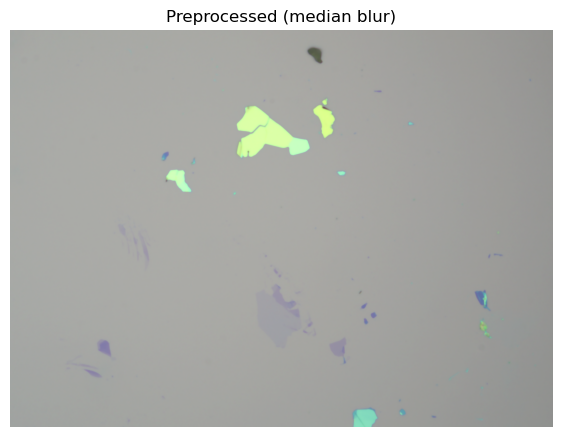

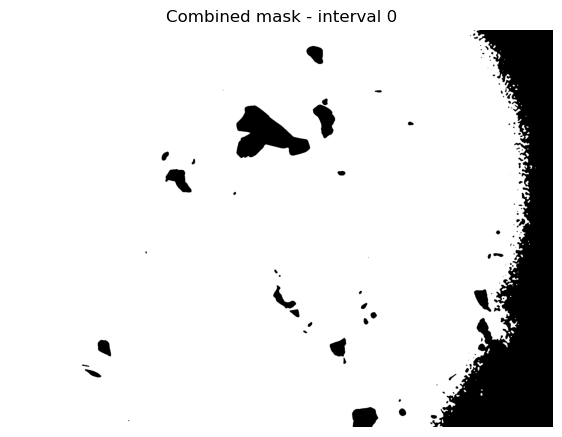

Found 3 flakes

Flake 0:
  Thickness interval: 0
  Area: 378 px
  Aspect ratio: 1.06
  KBGR median: (151, 152, 153, 149)
  KBGR std: (1.1, 1.9, 1.9, 2.1)

Flake 1:
  Thickness interval: 0
  Area: 291 px
  Aspect ratio: 1.02
  KBGR median: (153, 152, 153, 154)
  KBGR std: (1.1, 2.0, 2.0, 2.0)

Flake 2:
  Thickness interval: 0
  Area: 2766090 px
  Aspect ratio: 1.31
  KBGR median: (167, 164, 167, 167)
  KBGR std: (9.5, 5.9, 11.9, 8.3)


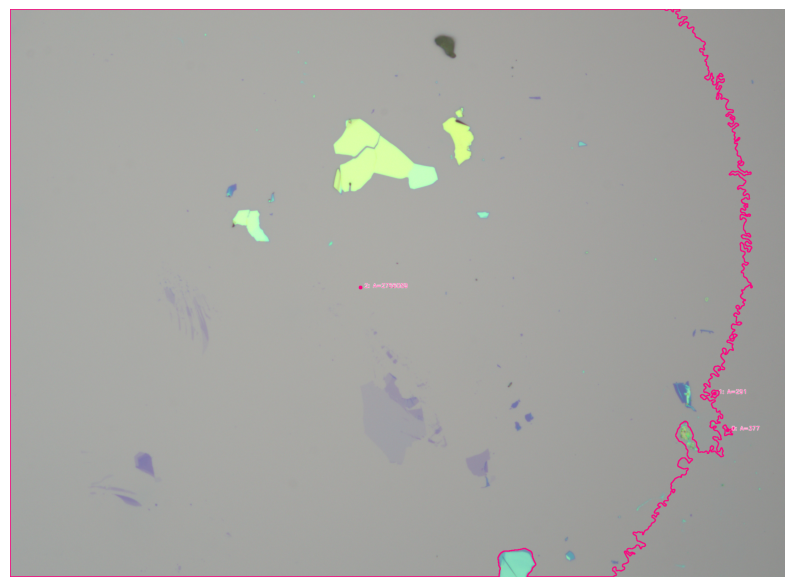

In [103]:
# Test the Flinder detector with calculated mask values

# Create detector instance
detector = FlinderDetector(config, debug=True)

# Use calculated monolayer mask values from cell 3
# Format: [kmin, kmax, bmin, bmax, gmin, gmax, rmin, rmax]
mask_values_list = [
    monolayer_mask_values,  # Monolayer - calculated from RGB(160, 166, 166)
]

# Detect flakes
print("Running Flinder detection algorithm...")
flakes = detector.detect_flakes(test_image_wb_bgr, mask_values_list, min_area=200)
print(f"Found {len(flakes)} flakes")

# Visualize results
vis_image = detector.visualize_flakes(test_image_wb_bgr, flakes)

# Print details of detected flakes
for idx, flake in enumerate(flakes):
    stats = flake['stats']
    print(f"\nFlake {idx}:")
    print(f"  Thickness interval: {flake['interval_idx']}")
    print(f"  Area: {stats['area']:.0f} px")
    print(f"  Aspect ratio: {stats['aspect_ratio']:.2f}")
    print(f"  KBGR median: ({stats['k_median']:.0f}, {stats['b_median']:.0f}, "
          f"{stats['g_median']:.0f}, {stats['r_median']:.0f})")
    print(f"  KBGR std: ({stats['k_std']:.1f}, {stats['b_std']:.1f}, "
          f"{stats['g_std']:.1f}, {stats['r_std']:.1f})")

showImage(vis_image)


In [104]:
# Diagnostic: Check actual colors in an image after white balance
# This helps verify if white balance is shifting the colors


# Extract KBGR channels
# b, g, r = cv2.split(test_image_wb_bgr)
# k_channel = cv2.cvtColor(test_image_wb_bgr, cv2.COLOR_BGR2GRAY)

# # Sample some pixels (you can adjust these coordinates)
# sample_y, sample_x = 500, 500  # Center-ish area
# if sample_y < test_image_wb_bgr.shape[0] and sample_x < test_image_wb_bgr.shape[1]:
    # print(f"Sample pixel at ({sample_x}, {sample_y}):")
    # print(f"  BGR: ({b[sample_y, sample_x]}, {g[sample_y, sample_x]}, {r[sample_y, sample_x]})")
    # print(f"  RGB: ({r[sample_y, sample_x]}, {g[sample_y, sample_x]}, {b[sample_y, sample_x]})")
    # print(f"  K (grayscale): {k_channel[sample_y, sample_x]}")
    # print(f"\nTarget monolayer:")
    # print(f"  BGR: ({b_target_bgr}, {g_target_bgr}, {r_target_bgr})")
    # print(f"  RGB: ({r_target_bgr}, {g_target_bgr}, {b_target_bgr})")
    # print(f"  K: {k_target}")
    
    # # Check if pixel is in range
    # k_val = k_channel[sample_y, sample_x]
    # b_val = b[sample_y, sample_x]
    # g_val = g[sample_y, sample_x]
    # r_val = r[sample_y, sample_x]
    
    # print(f"\nIn range check:")
    # print(f"  K: {mask_values_monolayer[0]} <= {k_val} <= {mask_values_monolayer[1]}? {mask_values_monolayer[0] <= k_val <= mask_values_monolayer[1]}")
    # print(f"  B: {mask_values_monolayer[2]} <= {b_val} <= {mask_values_monolayer[3]}? {mask_values_monolayer[2] <= b_val <= mask_values_monolayer[3]}")
    # print(f"  G: {mask_values_monolayer[4]} <= {g_val} <= {mask_values_monolayer[5]}? {mask_values_monolayer[4] <= g_val <= mask_values_monolayer[5]}")
    # print(f"  R: {mask_values_monolayer[6]} <= {r_val} <= {mask_values_monolayer[7]}? {mask_values_monolayer[6] <= r_val <= mask_values_monolayer[7]}")